# Inverted pendulum on a cart

Full python example of controlling an inverted pendulum on a cart following along with the lecture https://www.youtube.com/watch?v=qjhAAQexzLg&list=PLMrJAkhIeNNR20Mz-VpzgfQs5zrYi085m&index=12 from the excellent youtube playlist [Control Bootcamp](https://www.youtube.com/playlist?list=PLMrJAkhIeNNR20Mz-VpzgfQs5zrYi085m) by Steve Brunton

Here we calculate the equation of motion of the $\dot v$ and $\dot \omega$ using the Euler-Lagrange equation.

The dynamics are then linearised around the fixed point up position from which we can calculate control fource u that will keep the pendulum in the up position.

I am learning this so refer to lecture series for more, correct explanations

Note that my derivation of the equations of motion differ to that in the book and playlist. I am probable doing something wrong.

In [1]:
import sympy as sp
import numpy as np
import control as ct
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter

In [2]:
t, m, M, g, L, d, b = sp.symbols(r't m M g L \delta b')
x, the, u = sp.symbols(r'x \theta u', cls=sp.Function)

the = the(t)
the_d = sp.diff(the, t)
the_dd = sp.diff(the_d, t)

x = x(t)
x_d = sp.diff(x, t)
x_dd = sp.diff(x_d, t)

u = u(t)

In [3]:
values = {M: 5, m: 1, L: 2, g: 10, d: 1}

In [4]:
# Pend up x_pend is - L * sp.sin(the) but in pend down it is + L * sp.sin(the)
# With this tweak and I can't remember the logic behind it all, will generate the same odot and vdot as in the book,
# but the A matrix from this is different.
x_pend = - L * sp.sin(the) - x
y_pend = + L * sp.cos(the)
x_pend_d = sp.diff(x_pend, t)
y_pend_d = sp.diff(y_pend, t)

In [5]:
# Pend up x_pend is - L * sp.sin(the) but in pend down it is + L * sp.sin(the)
x_pend = + L * sp.sin(the) + x
y_pend = - L * sp.cos(the)
x_pend_d = sp.diff(x_pend, t)
y_pend_d = sp.diff(y_pend, t)

In [6]:
xpendf = sp.lambdify((the, x, L), x_pend)
ypendf = sp.lambdify((the, x, L), y_pend)

def get_coords(x, the, R):
    return x, np.zeros(x.shape), xpendf(the, x, R), ypendf(the, x, R)

#get_coords(0, 0, 2)

## Calculate dynamics of system

In [7]:
T = 1/2 * M * x_d ** 2 + 1/2 * m * (x_pend_d ** 2 + y_pend_d**2)
T

0.5*M*Derivative(x(t), t)**2 + 0.5*m*(L**2*sin(\theta(t))**2*Derivative(\theta(t), t)**2 + (L*cos(\theta(t))*Derivative(\theta(t), t) + Derivative(x(t), t))**2)

In [8]:
y_ground = L + y_pend
y_ground

-L*cos(\theta(t)) + L

In [9]:
v_ground_f = sp.lambdify(the, y_ground)
v_ground_f(0), v_ground_f(np.pi)

(0, 2.0*L)

In [10]:
V = m * g * y_ground
V

g*m*(-L*cos(\theta(t)) + L)

Lagrange equation

In [11]:
LE = T - V
LE

0.5*M*Derivative(x(t), t)**2 - g*m*(-L*cos(\theta(t)) + L) + 0.5*m*(L**2*sin(\theta(t))**2*Derivative(\theta(t), t)**2 + (L*cos(\theta(t))*Derivative(\theta(t), t) + Derivative(x(t), t))**2)

### Solve Euler-lagrange equation to find the equation of motion
`

In [12]:
W_x = sp.diff(sp.diff(LE, x_d), t) - sp.diff(LE, x)
W_x.simplify()

1.0*M*Derivative(x(t), (t, 2)) + 1.0*m*(-L*sin(\theta(t))*Derivative(\theta(t), t)**2 + L*cos(\theta(t))*Derivative(\theta(t), (t, 2)) + Derivative(x(t), (t, 2)))

In [13]:
W_the = sp.diff(sp.diff(LE, the_d), t) - sp.diff(LE, the)
W_the.simplify()

1.0*L*m*(L*Derivative(\theta(t), (t, 2)) + g*sin(\theta(t)) + cos(\theta(t))*Derivative(x(t), (t, 2)))

In [14]:
W_x2 = W_x + d * x_d - u

In [15]:
W_the2 = W_the

In [16]:
sols = sp.solve([W_x2, W_the2], [x_dd, the_dd])
sols[x_dd].simplify()

(L*m*sin(\theta(t))*Derivative(\theta(t), t)**2 - \delta*Derivative(x(t), t) + g*m*sin(2*\theta(t))/2 + u(t))/(M + m*sin(\theta(t))**2)

In [17]:
sols[the_dd].simplify()

(-L*m*sin(2*\theta(t))*Derivative(\theta(t), t)**2/2 - M*g*sin(\theta(t)) + \delta*cos(\theta(t))*Derivative(x(t), t) - g*m*sin(\theta(t)) - u(t)*cos(\theta(t)))/(L*(M + m*sin(\theta(t))**2))

In [18]:
S = sp.Matrix([
    x,
    x_d,
    the,
    the_d,
])
S

Matrix([
[                    x(t)],
[     Derivative(x(t), t)],
[               \theta(t)],
[Derivative(\theta(t), t)]])

In [19]:
f = sp.Matrix([
    x_d,
    sols[x_dd],
    the_d,
    sols[the_dd]
])
f.simplify()
f

Matrix([
[                                                                                                                                                                            Derivative(x(t), t)],
[                                                        (L*m*sin(\theta(t))*Derivative(\theta(t), t)**2 - \delta*Derivative(x(t), t) + g*m*sin(2*\theta(t))/2 + u(t))/(M + m*sin(\theta(t))**2)],
[                                                                                                                                                                       Derivative(\theta(t), t)],
[(-L*m*sin(2*\theta(t))*Derivative(\theta(t), t)**2/2 - M*g*sin(\theta(t)) + \delta*cos(\theta(t))*Derivative(x(t), t) - g*m*sin(\theta(t)) - u(t)*cos(\theta(t)))/(L*(M + m*sin(\theta(t))**2))]])

## Linearise dynamics arouund fixed point

At fix point the = sp.pi - pointing up we need to find A and B such that dS = Ax + Bu

$S = \begin{bmatrix}
x_1 \\
x_2 \\
x_3 \\
x_4 \\
\end{bmatrix} = \begin{bmatrix}
x \\
v \\
\theta \\
\omega
\end{bmatrix}$ so $dS = \begin{bmatrix}
v \\
\dot v \\
\omega \\
\dot \omega 
\end{bmatrix} = f(x)$

The jacobian is $\frac{Df}{Dx}|_{\bar x} = \begin{bmatrix}
\frac{\partial f_1}{\partial x} & \frac{\partial f_1}{\partial v} & \frac{\partial f_1}{\partial \theta} & \frac{\partial f_1}{\partial \omega} \\
\frac{\partial f_2}{\partial x} & \frac{\partial f_2}{\partial v} & \frac{\partial f_2}{\partial \theta} & \frac{\partial f_2}{\partial \omega} \\
\frac{\partial f_3}{\partial x} & \frac{\partial f_3}{\partial v} & \frac{\partial f_3}{\partial \theta} & \frac{\partial f_3}{\partial \omega} \\
\frac{\partial f_4}{\partial x} & \frac{\partial f_4}{\partial v} & \frac{\partial f_4}{\partial \theta} & \frac{\partial f_4}{\partial \omega} \\
\end{bmatrix}$

And this is our linearized dynamics matrix $A$

In [20]:
A = f.jacobian(S).subs({the: sp.pi})
A.simplify()
A

Matrix([
[0,             1,                 0, 0],
[0,     -\delta/M,             g*m/M, 0],
[0,             0,                 0, 1],
[0, -\delta/(L*M), (M*g + g*m)/(L*M), 0]])

Now B comes from the youtube / DataBook - I do not know how this was derived but it works

In [21]:
B = sp.Matrix([
    0,
    1 / M,
    0,
    1 / (M * L)
])
B

Matrix([
[      0],
[    1/M],
[      0],
[1/(L*M)]])

In [22]:
A_up = A.subs(values)
B_up = B.subs(values)
A_up

Matrix([
[0,     1, 0, 0],
[0,  -1/5, 2, 0],
[0,     0, 0, 1],
[0, -1/10, 6, 0]])

In [23]:
A_up2 = np.array(A_up, dtype=np.float64)
B_up2 = np.array(B_up, dtype=np.float64)
np.linalg.eig(A_up2).eigenvalues

array([ 0.        +0.j, -2.46742895+0.j, -0.16651192+0.j,  2.43394087+0.j])

## Controllability

Test system is controllable around the fixed point up

Calculate the controlablity matrix for A and B and if it has full rank (4) then system is controllable.

In [24]:
C = ct.ctrb(A_up2, B_up2)
np.linalg.matrix_rank(C)

np.int64(4)

## Calculate optimal control

So the A, C system is controllable

So we want to develop proportional controller K such that u = -K x controls the system

$\dot x = A x + B u$

So $\dot x = A x - B K x = (A - B K) x$


In [25]:
eigs = [-1.1, -1.2, -1.3, -1.4]
K = ct.place(A_up2, B_up2, eigs)
K

array([[ -2.4024,  -8.75  , 158.3048,  65.5   ]])

In [26]:
np.linalg.eig(A_up2 - B_up2 * K).eigenvalues

array([-1.4+0.j, -1.3+0.j, -1.2+0.j, -1.1+0.j])

In [27]:
p = [-0.3, -0.4, -0.5, -0.6]
p = [-1, -1.1, -1.2, -1.3]  # working but a bit slow getting there
p = [-3, -3.1, -3.2, -3.3]  # to aggresive and blows up
K = ct.place(A_up2, B_up2, p)
K

array([[ -98.208     , -125.866     ,  851.51599999,  375.73199999]])

In [28]:
# Design LQR controller - TODO
Q = np.eye(4)   # np.diag(np.array([1, 1, 10, 100]))
R = .0001
#K, S, E = ct.lqr(A_up2, B_up2, Q, R)
#K

## Simulate and draw the dynamic system

In [29]:
f.subs(values)

Matrix([
[                                                                                                                                       Derivative(x(t), t)],
[                                  (u(t) + 2*sin(\theta(t))*Derivative(\theta(t), t)**2 + 5*sin(2*\theta(t)) - Derivative(x(t), t))/(sin(\theta(t))**2 + 5)],
[                                                                                                                                  Derivative(\theta(t), t)],
[(-u(t)*cos(\theta(t)) - 60*sin(\theta(t)) - sin(2*\theta(t))*Derivative(\theta(t), t)**2 + cos(\theta(t))*Derivative(x(t), t))/(2*(sin(\theta(t))**2 + 5))]])

In [30]:
args = [*list(S), u]
f_lambda = sp.lambdify(args, f.subs(values))

In [31]:
def dSdt(S, t, uf):    
    u = uf(S)

    return f_lambda(*S, u).T[0]

In [32]:
t = np.linspace(0, 10, 1000)

y0 = [-1, 0, np.pi * 0.9, 0]

wr = np.array([1, 0, np.pi, 0])
uf = lambda S: np.dot(-K, (S - wr))[0]

ans = odeint(dSdt, y0=y0, t=t, args=(uf,))
cart_x, cart_y, pend_x, pend_y = get_coords(ans.T[0], ans.T[2], 2)

Text(0.5, 0, 'Time(sec)')

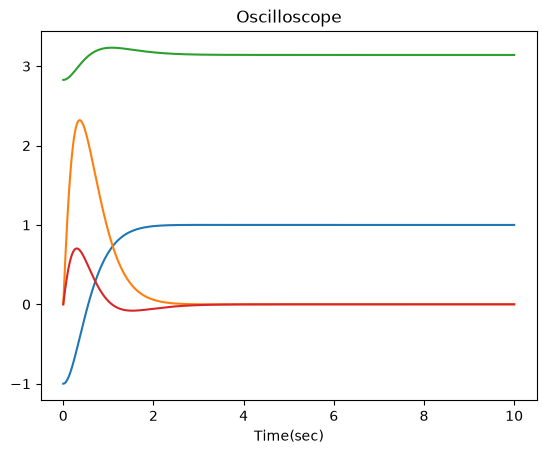

In [33]:
plt.title("Oscilloscope")
plt.plot(t, ans.T[0], label="Cart x")
plt.plot(t, ans.T[1], label="Cart xdot")
plt.plot(t, ans.T[2], label="Theta")
plt.plot(t, ans.T[3], label="Theta dot")
plt.xlabel("Time(sec)")

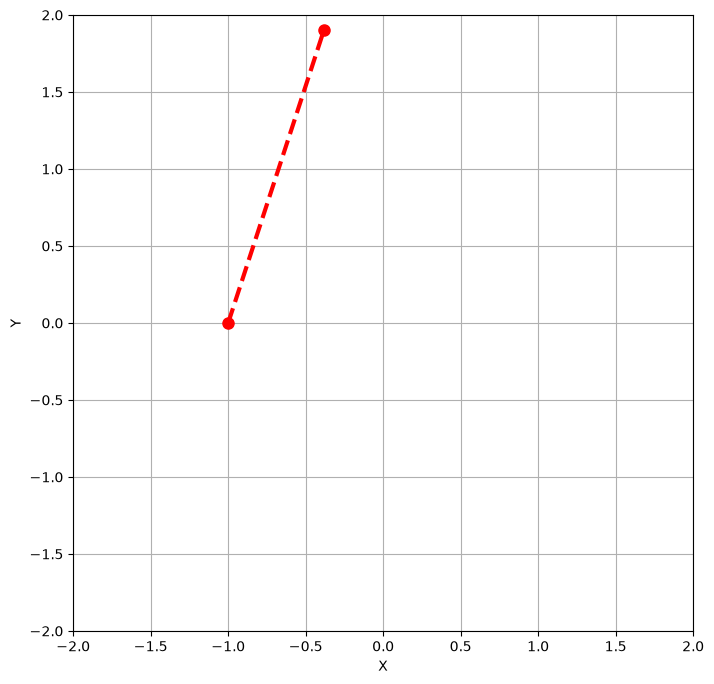

In [34]:
# Animation generates gif file which is really slow. See the corresponding python copied from here that is a lot quicker
def animate(i):
    ln1.set_data([cart_x[i], pend_x[i]], [cart_y[i], pend_y[i]])

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.grid()
ln1, = plt.plot([], [], 'ro--', lw=3, markersize=8)
ax.set_ylim(-2, 2)
ax.set_xlim(-2,2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ani = animation.FuncAnimation(fig, animate, frames=1000, interval=50)
ani.save('inverted-pendulum-on-cart.gif',writer='pillow',fps=50)

## Observability



In [35]:
C = [1, 0, 0, 0]

ct.obsv(A_up2, C)

array([[ 1.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  ,  0.  ],
       [ 0.  , -0.2 ,  2.  ,  0.  ],
       [ 0.  ,  0.04, -0.4 ,  2.  ]])

In [36]:
np.linalg.det(ct.obsv(A_up2, C))

np.float64(4.0)

If we only measure theta then the system is not observable

In [37]:
Ct = [0, 0, 1, 0]
Ot = ct.obsv(A_up2, Ct)
np.linalg.det(Ot)

np.float64(0.0)

If I don't care about x we can find it is observable

In [38]:
A3 = A_up2[1:, 1:]
B3 = B_up2[1:]
C3 = np.array([0, 1, 0])

O = ct.obsv(A3, C3)
O

array([[ 0. ,  1. ,  0. ],
       [ 0. ,  0. ,  1. ],
       [-0.1,  6. ,  0. ]])

In [39]:
np.linalg.det(O)

np.float64(-0.10000000000000002)

The system in the up direction is unstable!

In [40]:
D = np.zeros((1, 1))

sys = ct.ss(A3, B3, C3, D)
g = ct.gram(sys, 'o')

ValueError: Oops, the system is unstable!